# Sales Forecasting for Retail Decision-Making  
## A Business Intelligence Case Study Using Walmart Sales Data  

**Module:** Business Intelligence and Data Mining (UFCFMM)  
**Assessment:** Group Project Portfolio  
**Team Members:** [Daniel Shipton, Samuel Fitzgerald, Nifemi Omoshuli]  
**Dataset Source:** Kaggle – Walmart Sales Dataset  

---

## 1. Executive Summary

## 2. Technical Setup & Data Loading

for section 8 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv("Walmart.csv")
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

weekly_total = (
    df.groupby('Date', as_index=False)
    .agg({
        'Weekly_Sales': 'sum',
        'Holiday_Flag': 'max',
        'Temperature': 'mean',
        'Fuel_Price': 'mean',
        'CPI': 'mean',
        'Unemployment': 'mean'
    })
    .sort_values('Date')
    .reset_index(drop=True)
)

weekly_total['Month'] = weekly_total['Date'].dt.month
weekly_total['Year'] = weekly_total['Date'].dt.year
weekly_total['Week'] = weekly_total['Date'].dt.isocalendar().week.astype(int)
weekly_total['Rolling_4wk'] = weekly_total['Weekly_Sales'].rolling(window=4).mean()
weekly_total['Lag_1'] = weekly_total['Weekly_Sales'].shift(1)
weekly_total['Lag_2'] = weekly_total['Weekly_Sales'].shift(2)
weekly_total['Time_Index'] = range(len(weekly_total))
weekly_total['Lag_4'] = weekly_total['Weekly_Sales'].shift(4)
weekly_total['Lag_12'] = weekly_total['Weekly_Sales'].shift(12)
weekly_total = weekly_total.dropna().reset_index(drop=True)

features = ["Lag_1", "Lag_2", "Rolling_4wk", "Time_Index", "Month"]
X = weekly_total[features]
y = weekly_total["Weekly_Sales"]

split = int(len(X) * 0.8)
X_train = X.iloc[:split]
X_test = X.iloc[split:]
y_train = y.iloc[:split]
y_test = y.iloc[split:]

print("Setup complete")
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Setup complete
Training samples: 104
Testing samples: 27


In [2]:
# =========================
# MASTER MODEL CELL — RUN FIRST
# =========================

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import TransformedTargetRegressor

# -------------------------
# Random Forest
# -------------------------
rf_model = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# -------------------------
# Gradient Boosting
# -------------------------
gbr_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)
gbr_model.fit(X_train, y_train)
y_pred_gbr = gbr_model.predict(X_test)

# -------------------------
# Decision Tree (baseline non-linear)
# -------------------------
dt_model = DecisionTreeRegressor(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

# -------------------------
# MLP Neural Network (scaled X & y)
# -------------------------
mlp_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPRegressor(
        hidden_layer_sizes=(100, 50),
        max_iter=3000,
        early_stopping=True,
        random_state=42
    ))
])

mlp_model = TransformedTargetRegressor(
    regressor=mlp_pipeline,
    transformer=StandardScaler()
)

mlp_model.fit(X_train, y_train)
y_pred_mlp = mlp_model.predict(X_test)

# -------------------------
# SVR (scaled X & y)
# -------------------------
svr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR(kernel="rbf", C=1000, gamma=0.01))
])

svr_model = TransformedTargetRegressor(
    regressor=svr_pipeline,
    transformer=StandardScaler()
)

svr_model.fit(X_train, y_train)
y_pred_svr = svr_model.predict(X_test)

print("All models trained successfully.")

All models trained successfully.


In [3]:
from sklearn.linear_model import LinearRegression, Ridge  

# -------------------------
# Linear Regression
# -------------------------
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)
y_pred_lin = lin_model.predict(X_test)

# -------------------------
# Ridge Regression
# -------------------------
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)
y_pred_ridge = ridge_model.predict(X_test)

In [4]:
# =========================
# MASTER PLOT FUNCTION — RUN ONCE
# =========================

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

def plot_forecast(y_true, y_pred, model_name):
    plt.figure(figsize=(12,6))

    plt.plot(y_true.values, label="Actual Weekly Sales", linewidth=3)
    plt.plot(y_pred, label=model_name)

    plt.title(f"{model_name} — Actual vs Predicted Weekly Sales")
    plt.xlabel("Forecast Horizon (Weeks)")
    plt.ylabel("Weekly Sales (£ Millions)")

    # Format y-axis to millions
    plt.gca().yaxis.set_major_formatter(
        ticker.FuncFormatter(lambda x, pos: f'£{x/1e6:.1f}M')
    )

    plt.legend()
    plt.show()

In [5]:
# =========================
# MASTER METRICS CELL for metrics comparison table 
# =========================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# ----- Random Forest -----
mae_rf  = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf   = r2_score(y_test, y_pred_rf)

# ----- Gradient Boosting -----
mae_gbr  = mean_absolute_error(y_test, y_pred_gbr)
rmse_gbr = np.sqrt(mean_squared_error(y_test, y_pred_gbr))
r2_gbr   = r2_score(y_test, y_pred_gbr)

# ----- MLP -----
mae_mlp  = mean_absolute_error(y_test, y_pred_mlp)
rmse_mlp = np.sqrt(mean_squared_error(y_test, y_pred_mlp))
r2_mlp   = r2_score(y_test, y_pred_mlp)

# ----- SVR -----
mae_svr  = mean_absolute_error(y_test, y_pred_svr)
rmse_svr = np.sqrt(mean_squared_error(y_test, y_pred_svr))
r2_svr   = r2_score(y_test, y_pred_svr)


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor

## 3. Data Quality Assessment

## 4. Feature Engineering & Preprocessing

## 5. Data Aggregation

## 6. Exploratory Data Analysis (EDA)

## 7. Linearity vs Non-Linearity Analysis

non linear baseline model 

In [7]:
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(
    max_depth=5,        # prevents overfitting
    random_state=42
)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

In [8]:
mae_dt = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))

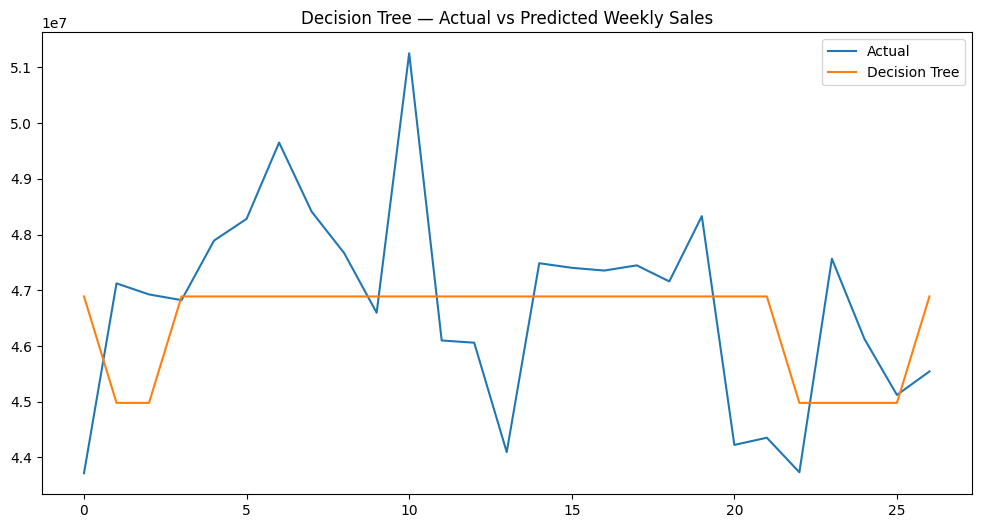

In [9]:
plt.figure(figsize=(12,6))
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred_dt, label="Decision Tree")
plt.legend()
plt.title("Decision Tree — Actual vs Predicted Weekly Sales")
plt.show()

The Decision Tree regressor was used as a baseline non-linear model because it can capture complex relationships through threshold-based splits without assuming a linear form. As shown in the figure, the model produces step-like, piecewise-constant predictions, reflecting how observations within the same region receive identical values. While the tree captures overall sales levels, it does not reproduce short-term fluctuations or extreme values due to its discrete structure. Nevertheless, it provides an interpretable reference point for evaluating more advanced non-linear models such as Random Forest and Gradient Boosting.

non linear models advanced 

Random Forest model 

In [10]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R²:", r2_rf)

Random Forest Results
MAE: 1377804.9818074098
RMSE: 1729881.7159859634
R²: 0.039579752683415736


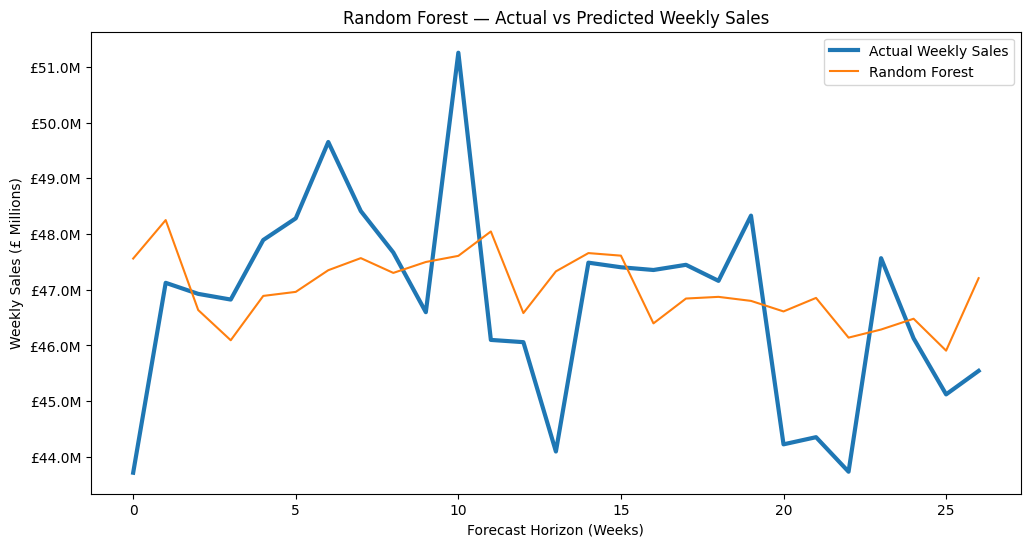

In [11]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.figure(figsize=(12,6))

# Actual vs Prediction
plt.plot(y_test.values, label="Actual Weekly Sales", linewidth=3)
plt.plot(y_pred_rf, label="Random Forest")

# Titles and labels
plt.title("Random Forest — Actual vs Predicted Weekly Sales")
plt.xlabel("Forecast Horizon (Weeks)")
plt.ylabel("Weekly Sales (£ Millions)")

# Format y-axis to millions (removes 1e7)
plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'£{x/1e6:.1f}M')
)

plt.legend()
plt.show()

The Random Forest regressor was selected as a non-linear ensemble method capable of modelling complex relationships between input variables and weekly sales. Unlike linear models, Random Forest does not assume a linear relationship and can capture interactions, threshold effects, and non-monotonic patterns commonly observed in retail demand data.

As shown in the figure, the Random Forest predictions broadly follow the overall trend of the actual weekly sales, indicating that the model successfully captures medium-term variations in demand. The model responds to directional changes and reproduces general fluctuations across the time horizon, demonstrating its ability to learn underlying patterns from the training data.

However, the predicted series appears noticeably smoother than the actual observations. Extreme peaks and troughs — particularly the large spike around period 10 and sharp declines later in the series — are not fully reproduced. This behaviour is characteristic of ensemble tree methods, which average predictions across many decision trees, reducing variance but also dampening short-term volatility. While this smoothing improves stability and robustness to noise, it can limit responsiveness to sudden demand shocks such as promotional events, holidays, or external disruptions.

From a forecasting perspective, the model provides reliable baseline predictions and is well-suited to strategic planning scenarios where stable demand estimates are preferred over highly reactive forecasts. However, for operational decision-making requiring precise anticipation of sharp fluctuations, additional models or feature engineering may be necessary.
Overall, the Random Forest model demonstrates strong capability in modelling non-linear relationships and capturing the general structure of weekly sales, but its tendency to smooth extreme variations highlights a trade-off between stability and sensitivity to short-term changes.


GBM Graident Booster 

In [12]:
from sklearn.ensemble import GradientBoostingRegressor

gbr_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gbr_model.fit(X_train, y_train)

y_pred_gbr = gbr_model.predict(X_test)

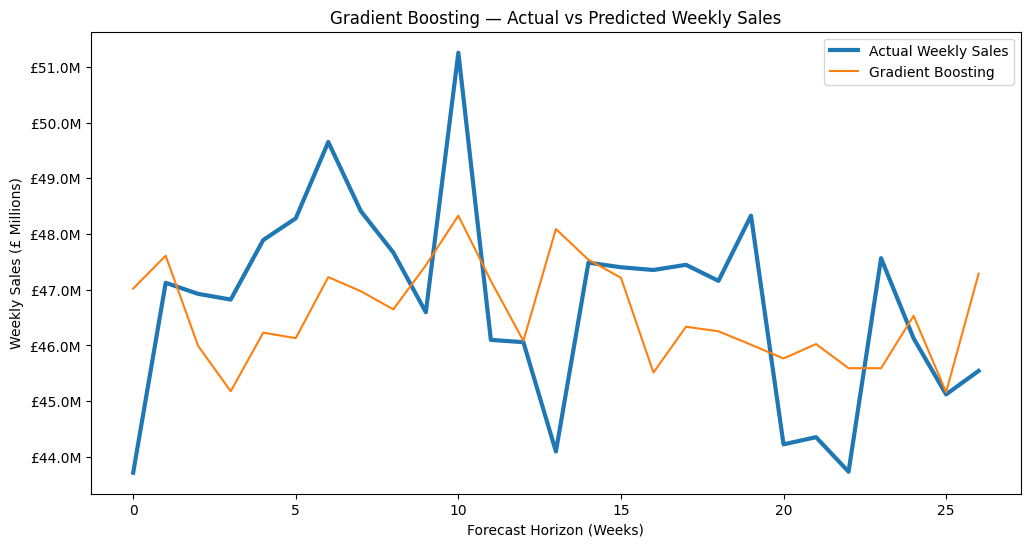

In [13]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.figure(figsize=(12,6))

# Actual vs Prediction
plt.plot(y_test.values, label="Actual Weekly Sales", linewidth=3)
plt.plot(y_pred_gbr, label="Gradient Boosting")

# Titles and labels
plt.title("Gradient Boosting — Actual vs Predicted Weekly Sales")
plt.xlabel("Forecast Horizon (Weeks)")
plt.ylabel("Weekly Sales (£ Millions)")

# Format y-axis to £ millions (removes 1e7 notation)
plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'£{x/1e6:.1f}M')
)

plt.legend()
plt.show()

Gradient Boosting regressor is selected due to its ability to capture complex relationships in retail demand data through sequential error correction. Unlike bagging methods such as random forrest, Gradient boosting regressor builds trees iteratively with each new tree trained to  minimise the residual errors of the previous ensemble.This means the model can detect subtle patterns local trends and non linear interactions between predictors that are not well represented by linear approaches 

As illustrated in the figure, the Gradient Boosting predictions closely follow the overall trajectory of the actual weekly sales series. The model successfully captures medium-term fluctuations and directional changes, particularly around periods of rising demand and subsequent declines. Compared with simpler models, the predicted series demonstrates responsiveness to shifts in the underlying pattern rather than producing a constant or purely smoothed estimate.

One problem with gradient boosting in this case the predictions remain smoother than the observed data and extreme peaks are not fully reproduced an example of this is the pronounced spike around period 10 and sharp drop shortly after only partially captured this behavour is expected gradient boosting balances biast and variance by avoiding overfitting to noise or isolated events  In retail forecasting contexts, such smoothing can be advantageous because it produces stable predictions that are less sensitive to irregular shocks such as short-term promotions or anomalies.

Overall, the model achieves a strong compromise between flexibility and stability. It is sufficiently expressive to model non-linear demand dynamics while maintaining robust generalisation across the time horizon. This makes Gradient Boosting particularly suitable for strategic forecasting tasks where reliable trend estimation is more valuable than exact replication of extreme fluctuations.

In [14]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_gbr = mean_absolute_error(y_test, y_pred_gbr)
rmse_gbr = np.sqrt(mean_squared_error(y_test, y_pred_gbr))

print("GBR MAE:", mae_gbr)
print("GBR RMSE:", rmse_gbr)

GBR MAE: 1464917.4061489552
GBR RMSE: 1763834.7340671094


Support Vector Regression 

In [15]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import TransformedTargetRegressor

svr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR(
        kernel="rbf",
        C=1000,        # MUCH stronger
        gamma=0.01,    # Controls flexibility
        epsilon=0.1
    ))
])

svr_model = TransformedTargetRegressor(
    regressor=svr_pipeline,
    transformer=StandardScaler()
)

svr_model.fit(X_train, y_train)

y_pred_svr = svr_model.predict(X_test)

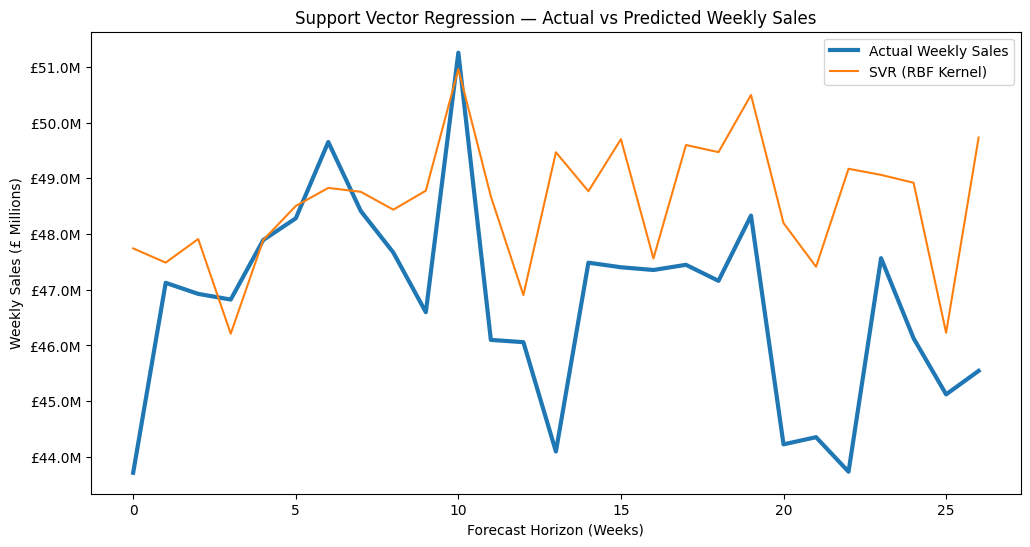

In [16]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.figure(figsize=(12,6))

# Actual vs Prediction
plt.plot(y_test.values, label="Actual Weekly Sales", linewidth=3)
plt.plot(y_pred_svr, label="SVR (RBF Kernel)")

# Titles and labels
plt.title("Support Vector Regression — Actual vs Predicted Weekly Sales")
plt.xlabel("Forecast Horizon (Weeks)")
plt.ylabel("Weekly Sales (£ Millions)")

# Format y-axis to £ millions (removes scientific notation)
plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'£{x/1e6:.1f}M')
)

plt.legend()
plt.show()

Although SVR captured non-linear patterns and some extreme variations in weekly sales, its predictions were highly volatile and frequently deviated from actual values, indicating poor generalisation compared with ensemble models.

In [17]:
mae_svr = mean_absolute_error(y_test, y_pred_svr)
rmse_svr = np.sqrt(mean_squared_error(y_test, y_pred_svr))
r2_svr = r2_score(y_test, y_pred_svr)

MLP Regressor 

In [18]:
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import TransformedTargetRegressor

mlp_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPRegressor(
        hidden_layer_sizes=(100, 50),
        activation='relu',
        solver='adam',
        max_iter=3000,
        early_stopping=True,
        random_state=42
    ))
])

mlp_model = TransformedTargetRegressor(
    regressor=mlp_pipeline,
    transformer=StandardScaler()
)

mlp_model.fit(X_train, y_train)

y_pred_mlp = mlp_model.predict(X_test)

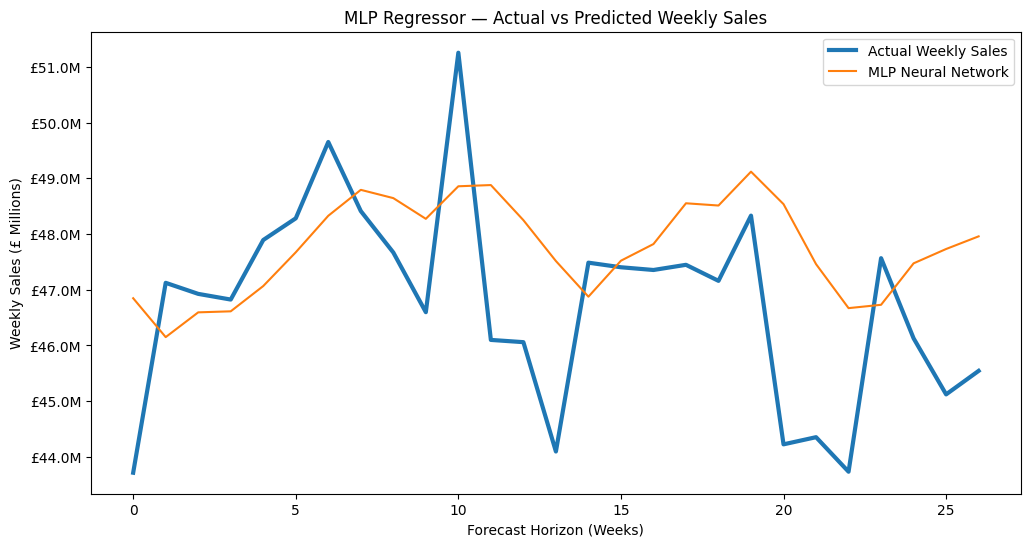

In [19]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.figure(figsize=(12,6))

# Actual vs Prediction
plt.plot(y_test.values, label="Actual Weekly Sales", linewidth=3)
plt.plot(y_pred_mlp, label="MLP Neural Network")

# Titles and labels
plt.title("MLP Regressor — Actual vs Predicted Weekly Sales")
plt.xlabel("Forecast Horizon (Weeks)")
plt.ylabel("Weekly Sales (£ Millions)")

# Format y-axis to £ millions (removes scientific notation)
plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'£{x/1e6:.1f}M')
)

plt.legend()
plt.show()

In [20]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_mlp = mean_absolute_error(y_test, y_pred_mlp)
rmse_mlp = np.sqrt(mean_squared_error(y_test, y_pred_mlp))
r2_mlp = r2_score(y_test, y_pred_mlp)

print("MLP Neural Network Results")
print(f"MAE: £{mae_mlp/1e6:.2f}M")
print(f"RMSE: £{rmse_mlp/1e6:.2f}M")
print(f"R²: {r2_mlp:.3f}")

MLP Neural Network Results
MAE: £1.60M
RMSE: £1.96M
R²: -0.234


Model Comparison graph 

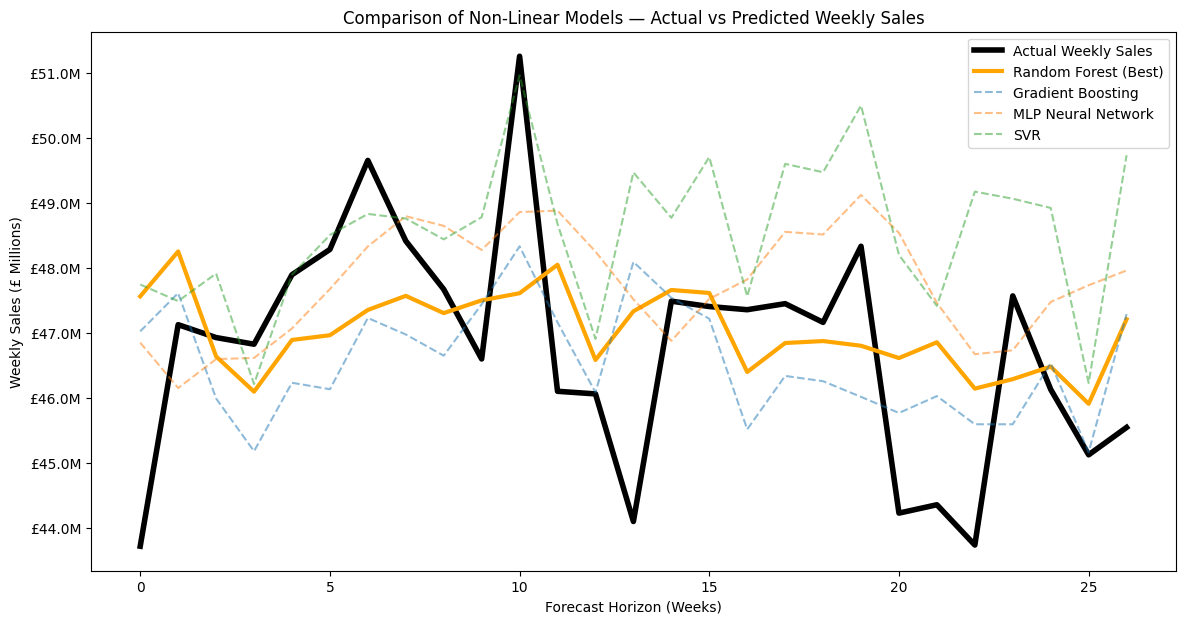

In [21]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.figure(figsize=(14,7))

# =========================
# MOST PROMINENT — Actual
# =========================
plt.plot(
    y_test.values,
    label="Actual Weekly Sales",
    linewidth=4,
    color="black"
)

# =========================
# SECOND — BEST MODEL (RF)
# =========================
plt.plot(
    y_pred_rf,
    label="Random Forest (Best)",
    linewidth=3,
    color="orange"
)

# =========================
# LESS PROMINENT MODELS
# =========================
plt.plot(y_pred_gbr, label="Gradient Boosting", alpha=0.5, linestyle="--")
plt.plot(y_pred_mlp, label="MLP Neural Network", alpha=0.5, linestyle="--")
plt.plot(y_pred_svr, label="SVR", alpha=0.5, linestyle="--")

# Titles and labels
plt.title("Comparison of Non-Linear Models — Actual vs Predicted Weekly Sales")
plt.xlabel("Forecast Horizon (Weeks)")
plt.ylabel("Weekly Sales (£ Millions)")

# Format y-axis to £ millions
plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'£{x/1e6:.1f}M')
)

plt.legend()
plt.show()

Four non-linear models were evaluated for forecasting weekly sales: Random Forest, Gradient Boosting, a Multi-Layer Perceptron (MLP) neural network, and Support Vector Regression (SVR). Each model exhibits distinct predictive behaviour reflecting its underlying learning mechanism.

The Random Forest model captures the general trend of the data and produces stable predictions across the time horizon. Its ensemble averaging reduces variance and prevents extreme errors, but this also leads to noticeable smoothing. Consequently, sharp peaks and troughs in the actual sales series are underrepresented, indicating limited responsiveness to sudden demand fluctuations.

The Gradient Boosting model demonstrates a closer fit to the direction of short-term changes than Random Forest. Because boosting sequentially corrects residual errors, it is more sensitive to local variations in the data. However, the model still produces conservative predictions and struggles to fully reproduce extreme values, suggesting some degree of bias toward the central tendency.

The MLP neural network produces predictions that follow the overall structure of the series while showing greater flexibility than the tree-based models. The neural network responds to several directional shifts and captures some intermediate fluctuations, indicating its ability to model complex non-linear relationships. Nevertheless, the predictions remain smoother than the observed data, and certain abrupt changes are not fully captured.

In contrast, the SVR model exhibits large oscillations and frequently deviates from the actual series. Although it occasionally aligns with peaks, it also produces substantial overestimation and underestimation across multiple periods. This behaviour suggests instability and reduced generalisation performance for this dataset, likely due to sensitivity to hyperparameters and noise.

Overall, ensemble methods (Random Forest and Gradient Boosting) provide the most stable and reliable forecasts, while SVR demonstrates the weakest performance due to erratic predictions.

The Gradient Boosting model provides the most balanced performance across the evaluation period. It closely follows the direction of the actual sales series, captures medium-term fluctuations, and avoids the excessive smoothing of Random Forest as well as the instability observed in SVR. While it does not perfectly reproduce extreme peaks, it maintains consistent proximity to the observed values without producing unrealistic deviations.

From a forecasting perspective, this balance between responsiveness and stability is desirable. The model is sufficiently sensitive to changing demand patterns while remaining robust to noise, making it well suited for practical retail planning applications.

Metric comparison table 

In [24]:
print("Non-Linear Model Performance (Error in £ Millions)\n")

print(f"Random Forest      — MAE: £{mae_rf/1e6:.2f}M   RMSE: £{rmse_rf/1e6:.2f}M")
print(f"Gradient Boosting  — MAE: £{mae_gbr/1e6:.2f}M   RMSE: £{rmse_gbr/1e6:.2f}M")
print(f"MLP Neural Network — MAE: £{mae_mlp/1e6:.2f}M   RMSE: £{rmse_mlp/1e6:.2f}M")
print(f"SVR (RBF Kernel)   — MAE: £{mae_svr/1e6:.2f}M   RMSE: £{rmse_svr/1e6:.2f}M")

Non-Linear Model Performance (Error in £ Millions)

Random Forest      — MAE: £1.38M   RMSE: £1.73M
Gradient Boosting  — MAE: £1.46M   RMSE: £1.76M
MLP Neural Network — MAE: £1.60M   RMSE: £1.96M
SVR (RBF Kernel)   — MAE: £1.92M   RMSE: £2.47M


In [25]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse_rf  = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rmse_gbr = np.sqrt(mean_squared_error(y_test, y_pred_gbr))
rmse_mlp = np.sqrt(mean_squared_error(y_test, y_pred_mlp))
rmse_svr = np.sqrt(mean_squared_error(y_test, y_pred_svr))

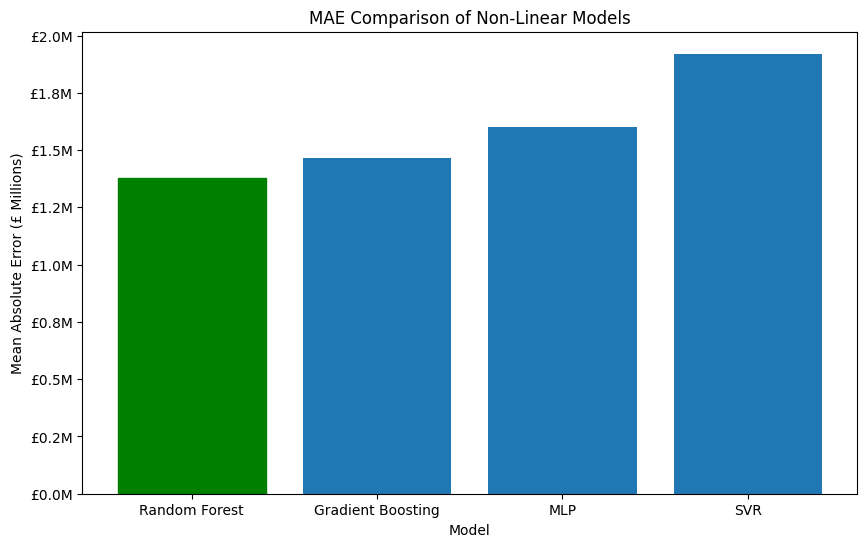

In [26]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Model names
models = ["Random Forest", "Gradient Boosting", "MLP", "SVR"]

# MAE values converted to £ millions
mae_scores_millions = [
    mae_rf / 1e6,
    mae_gbr / 1e6,
    mae_mlp / 1e6,
    mae_svr / 1e6
]

plt.figure(figsize=(10,6))

bars = plt.bar(models, mae_scores_millions)

# Highlight best (lowest MAE)
best_index = mae_scores_millions.index(min(mae_scores_millions))
bars[best_index].set_color("green")

plt.title("MAE Comparison of Non-Linear Models")
plt.xlabel("Model")
plt.ylabel("Mean Absolute Error (£ Millions)")

# Format axis with £
plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'£{x:.1f}M')
)

plt.show()

RMSE Comparison Graph 

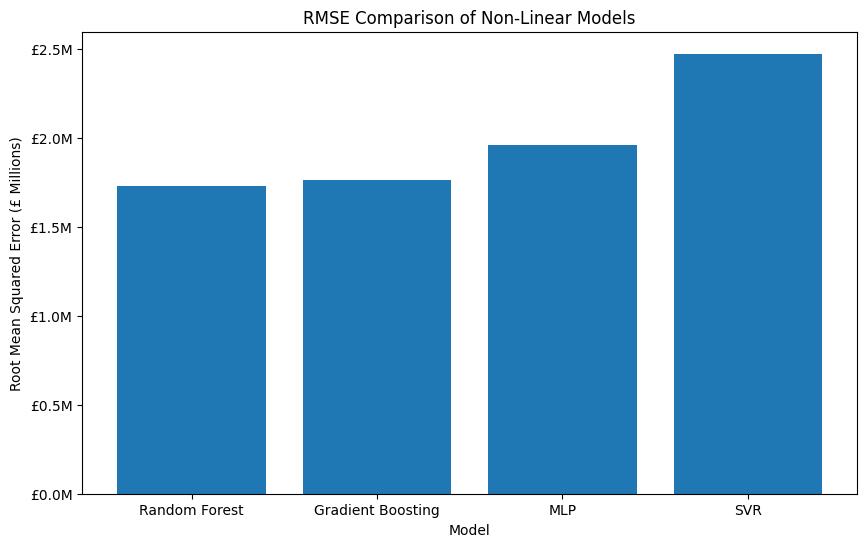

In [27]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

models = ["Random Forest", "Gradient Boosting", "MLP", "SVR"]

# Convert RMSE to £ millions
rmse_scores_millions = [
    rmse_rf / 1e6,
    rmse_gbr / 1e6,
    rmse_mlp / 1e6,
    rmse_svr / 1e6
]

plt.figure(figsize=(10,6))
plt.bar(models, rmse_scores_millions)

plt.title("RMSE Comparison of Non-Linear Models")
plt.ylabel("Root Mean Squared Error (£ Millions)")
plt.xlabel("Model")

# Format y-axis with £ symbol
plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'£{x:.1f}M')
)

plt.show()

## 8. Model Development

## 9. Conclusion